## Ejercicio 1: Evaluación de solicitud de crédito bancario

### Ficha PEAS
**Percepción (S)** = Ingreso mensual, monto solicitado, historial de moroso 
**Acciones (A)** = Aprobar, Aprobar con condiciones y Rechazar 
**Entorno (E)** = Sistema bancario de evaluación crediticia(accesible, determinista, estático, episódico) 
**Objetivo** = Minimizar el riesgo de impago aprobando solo créditos viables 
**Medida de desempeño (P)** = % de créditos aprobados bien pagados, % de rechazos injustos, consistencia en decisiones similares 

### Justificación de las reglas

Las reglas se basan en la relación monto/ingreso porque refleja directamente la capacidad de pago del solicitante frente a su ingreso real. Un historial moroso se considera un agravante, ya que indica riesgo de incumplimiento incluso con una relación baja. Combinar ambos criterios permite al banco aprobar créditos de bajo riesgo, imponer condiciones (como reducir el monto o exigir garantías) en casos intermedios, y rechazar los de alto riesgo, protegiendo la solvencia del banco sin ser excesivamente restrictivo con buenos pagadores.

### Explicacion del codigo
Calcula la relación monto/ingreso y decide según dos casos: si el cliente es moroso, aplica límites más estrictos (0.3); si no lo es, aplica límites más flexibles (0.3 y 0.5), retornando la acción y el motivo.

In [10]:
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    relacion = monto_solicitado / ingreso_mensual

    if tiene_historial_moroso:
        if relacion <= 0.3:
            return "aprobar con condiciones", "moroso con relacion baja"
        else:
            return "rechazar", "moroso con relacion alta"
    else:
        if relacion <= 0.3:
            return "aprobar", "relacion baja"
        elif relacion <= 0.5:
            return "aprobar con condiciones", "relacion media"
        else:
            return "rechazar", "relacion alta"

Se definen 6 solicitudes de prueba con distintos ingresos, montos e historial moroso, incluyendo casos límite donde la relación es exactamente 0.3 o 0.5

In [11]:
casos_prueba = [
    (3000, 500, False),    # relacion = 0.167 -> aprobar
    (2000, 1000, False),   # relacion = 0.5 -> caso limite (aprobar con condiciones)
    (2500, 1500, False),   # relacion = 0.6 -> rechazar
    (3000, 900, True),     # relacion = 0.3 -> caso limite con moroso (aprobar con condiciones)
    (3000, 1000, True),    # relacion = 0.333 -> rechazar (moroso)
    (1800, 900, True),     # relacion = 0.5 -> rechazar (moroso)
]

for ingreso, monto, moroso in casos_prueba:
    accion, motivo = agente_credito(ingreso, monto, moroso)
    print(f"Ingreso: {ingreso}, Monto: {monto}, Moroso: {moroso} -> {accion} ({motivo})")

Ingreso: 3000, Monto: 500, Moroso: False -> aprobar (relacion baja)
Ingreso: 2000, Monto: 1000, Moroso: False -> aprobar con condiciones (relacion media)
Ingreso: 2500, Monto: 1500, Moroso: False -> rechazar (relacion alta)
Ingreso: 3000, Monto: 900, Moroso: True -> aprobar con condiciones (moroso con relacion baja)
Ingreso: 3000, Monto: 1000, Moroso: True -> rechazar (moroso con relacion alta)
Ingreso: 1800, Monto: 900, Moroso: True -> rechazar (moroso con relacion alta)


Se recorre cada solicitud, se evalúa con el agente y se imprime la acción tomada junto con su motivo

### Visualización

Se importan las librerías necesarias: numpy para generar datos aleatorios, matplotlib para graficar

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

Se genera una semilla fija para reproducibilidad y se crean 200 ingresos, montos e historiales aleatorios

In [ ]:
np.random.seed(42)
n = 200
ingresos = np.random.uniform(800, 5000, n)
montos = np.random.uniform(100, 3000, n)
morosos = np.random.choice([True, False], n)

Se define un color para cada posible decisión del agente, y listas vacías para guardar los resultados

In [ ]:
colores_map = {"aprobar": "green", "aprobar con condiciones": "orange", "rechazar": "red"}
relaciones = []
colores = []

Se evalúa cada solicitud con el agente y se guarda su relación monto/ingreso junto con el color de su decisión

In [ ]:
for ingreso, monto, moroso in zip(ingresos, montos, morosos):
    accion, _ = agente_credito(ingreso, monto, moroso)
    relaciones.append(monto / ingreso)
    colores.append(colores_map[accion])

Se crea el gráfico de dispersión, coloreando cada punto según la decisión tomada

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(relaciones, ingresos, c=colores, alpha=0.7)
plt.xlabel("Relación monto/ingreso")
plt.ylabel("Ingreso mensual (S/)")
plt.title("Decisiones del agente de crédito (200 solicitudes)")

Se agrega una leyenda para identificar cada color y se muestra el gráfico final

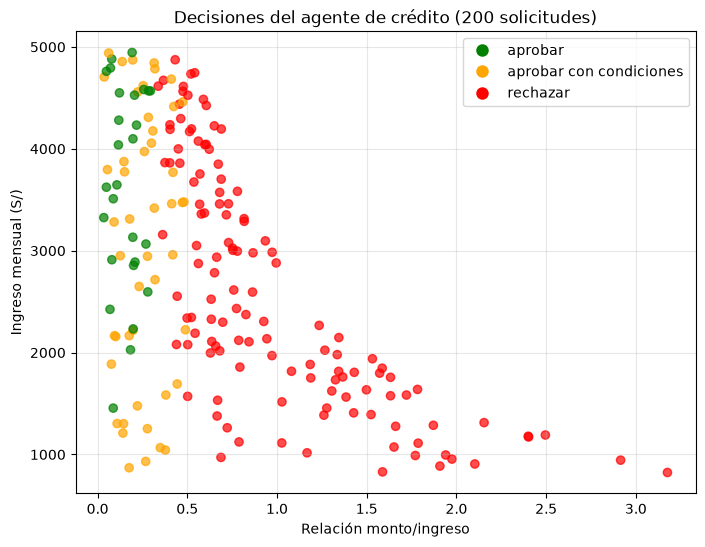

In [12]:
leyenda = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, label=l, markersize=10)
           for l, c in colores_map.items()]
plt.legend(handles=leyenda)
plt.grid(alpha=0.3)
plt.show()